# PCD Assignment 02
Nama: Dhimas Arya Cahya Nugraha \
NIM: 25/559644/PA/23548

# Blurred Image

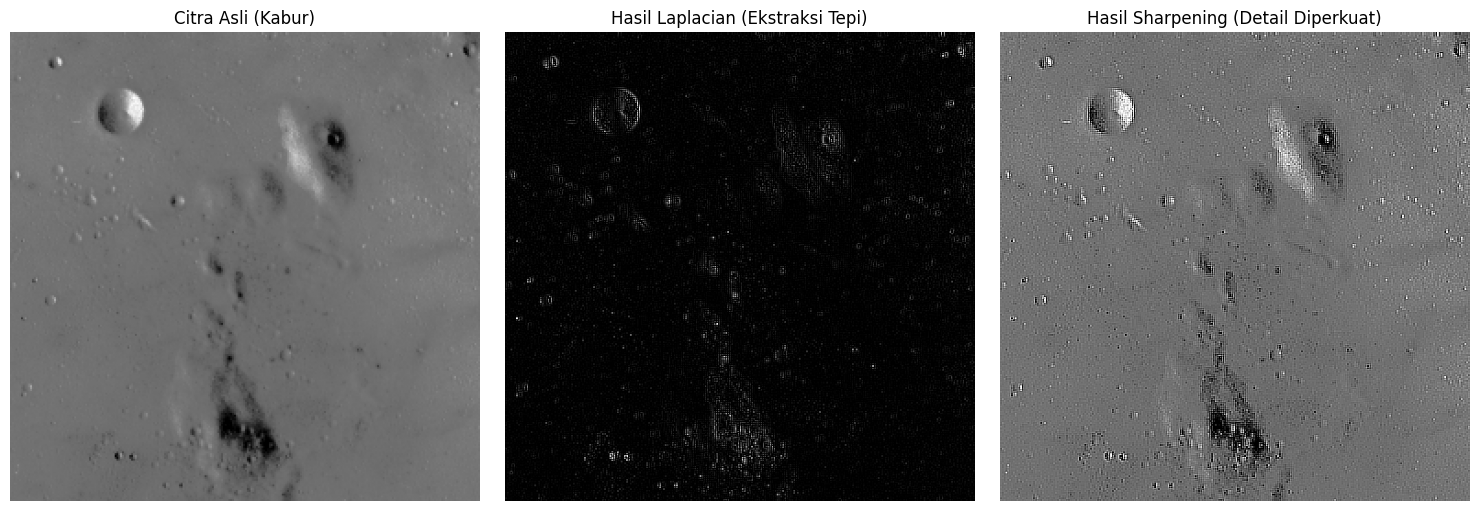

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

image = data.moon().astype(np.float64)

laplacian_mask = np.array([
    [1,  1,  1],
    [1, -8,  1],
    [1,  1,  1]
])

def convolve2d(img, kernel):
    pad_img = np.pad(img, ((1, 1), (1, 1)), mode='reflect')
    result = np.zeros_like(img)

    for i in range(3):
        for j in range(3):
            result += pad_img[i : i + img.shape[0], j : j + img.shape[1]] * kernel[i, j]

    return result
laplacian_edges = convolve2d(image, laplacian_mask)

image_sharpened = image - laplacian_edges
image_sharpened = np.clip(image_sharpened, 0, 255).astype(np.uint8)
laplacian_vis = np.clip(laplacian_edges, 0, 255).astype(np.uint8)
image_original = image.astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_original, cmap='gray')
axes[0].set_title('Citra Asli (Kabur)')
axes[0].axis('off')

axes[1].imshow(laplacian_vis, cmap='gray')
axes[1].set_title('Hasil Laplacian (Ekstraksi Tepi)')
axes[1].axis('off')

axes[2].imshow(image_sharpened, cmap='gray')
axes[2].set_title('Hasil Sharpening (Detail Diperkuat)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Dark Image

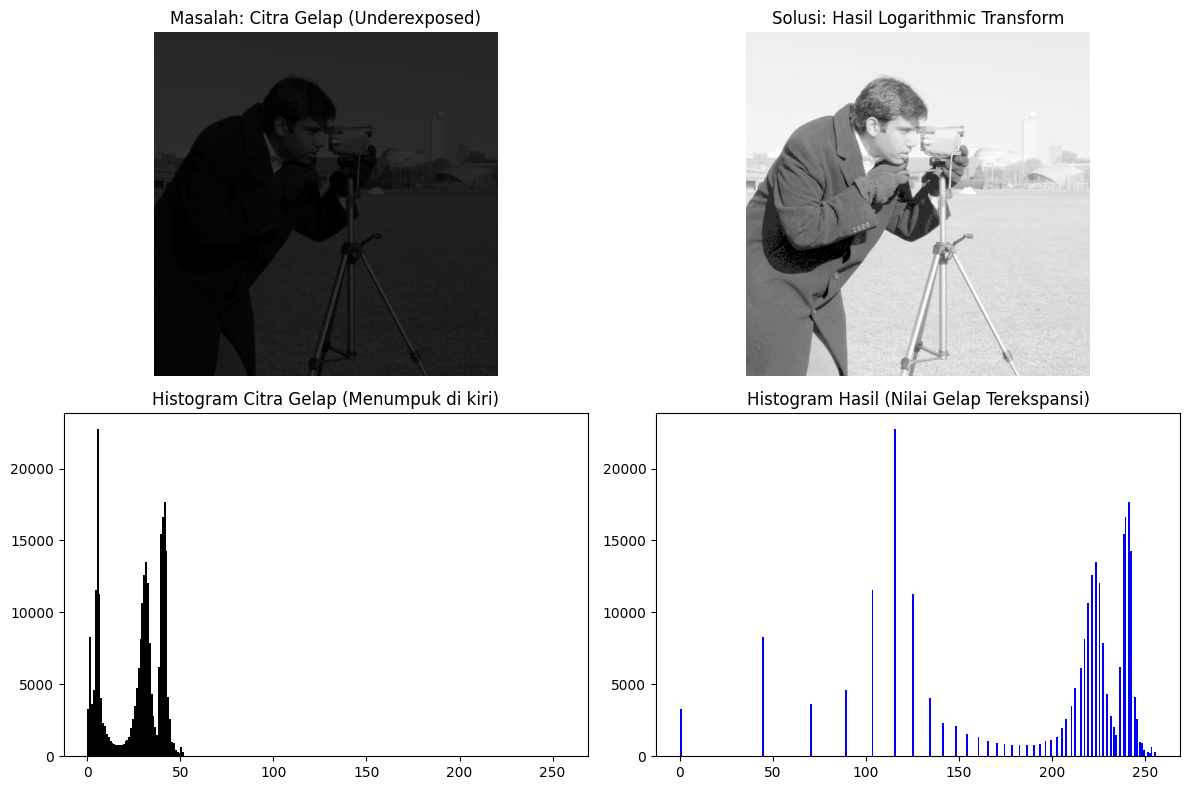

In [4]:
image_asli = data.camera()
image_dark = (image_asli * 0.2).astype(np.uint8)
r = image_dark.astype(np.float64)
c = 255.0 / np.log(1 + np.max(r))
s = c * np.log(1 + r)
image_enhanced = np.uint8(s)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(image_dark, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Citra Awal')
axes[0, 0].axis('off')

axes[1, 0].hist(image_dark.flatten(), bins=256, range=(0, 256), color='black')
axes[1, 0].set_title('Histogram Citra Gelap (Menumpuk di kiri)')

axes[0, 1].imshow(image_enhanced, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Solusi: Hasil Logarithmic Transform')
axes[0, 1].axis('off')

axes[1, 1].hist(image_enhanced.flatten(), bins=256, range=(0, 256), color='blue')
axes[1, 1].set_title('Histogram Hasil (Nilai Gelap Terekspansi)')

plt.tight_layout()
plt.show()

# Bright Image

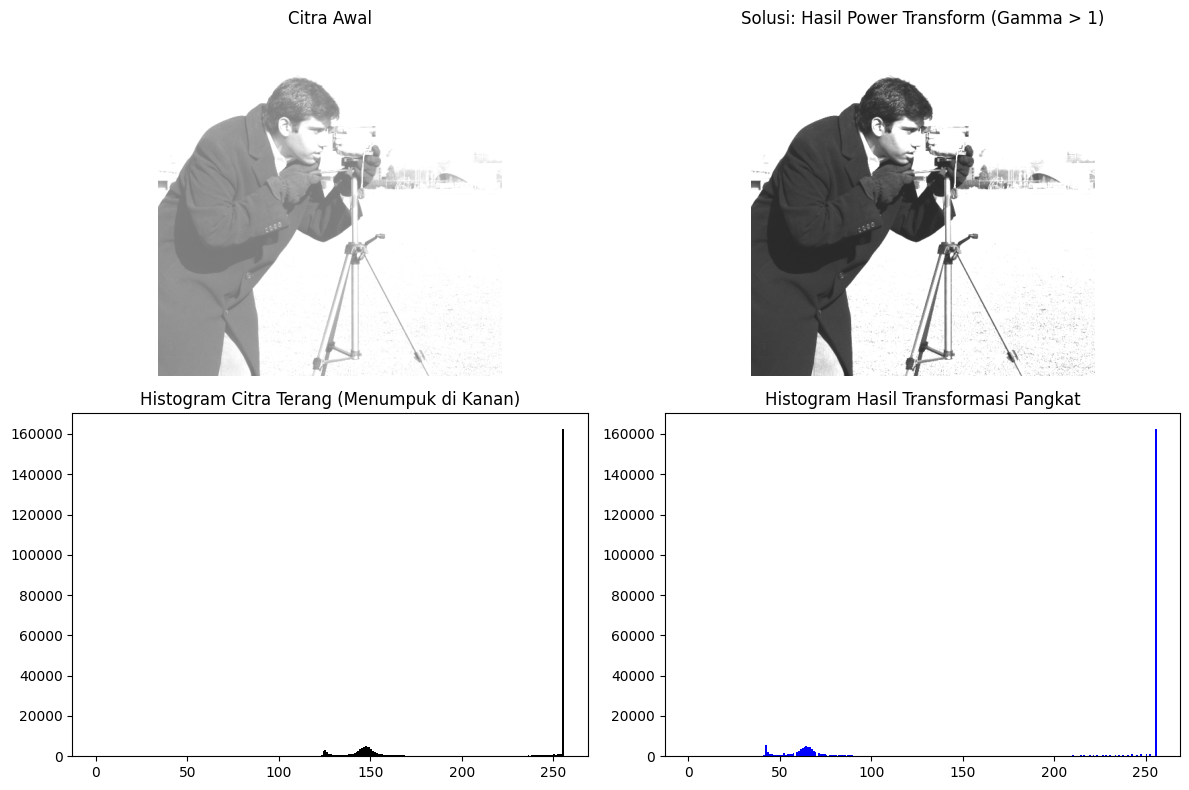

In [5]:
image_asli = data.camera()
image_bright = np.clip(image_asli.astype(np.float64) + 120, 0, 255).astype(np.uint8)

gamma = 2.5

r = image_bright.astype(np.float64) / 255.0

s = np.power(r, gamma)

image_enhanced = np.uint8(s * 255.0)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(image_bright, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Citra Overexposed')
axes[0, 0].axis('off')

axes[1, 0].hist(image_bright.flatten(), bins=256, range=(0, 256), color='black')
axes[1, 0].set_title('Histogram Citra Terang (Menumpuk di Kanan)')

axes[0, 1].imshow(image_enhanced, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Solusi: Hasil Power Transform (Gamma > 1)')
axes[0, 1].axis('off')

axes[1, 1].hist(image_enhanced.flatten(), bins=256, range=(0, 256), color='blue')
axes[1, 1].set_title('Histogram Hasil Transformasi Pangkat')

plt.tight_layout()
plt.show()

# Low Contrast Image

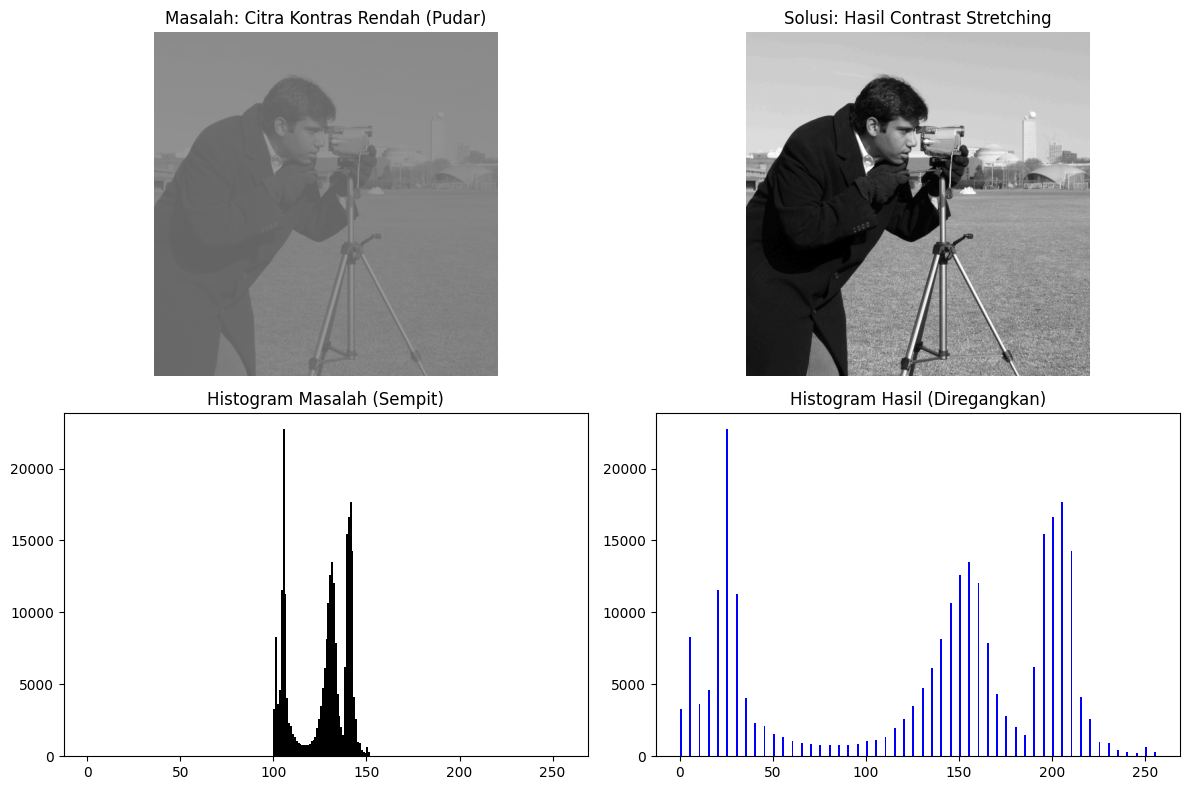

In [6]:
image_asli = data.camera()
image_low_contrast = (image_asli * 0.2 + 100).astype(np.uint8)

min_val = np.min(image_low_contrast)
max_val = np.max(image_low_contrast)

P_in = image_low_contrast.astype(np.float64)
P_out = (P_in - min_val) * (255.0 / (max_val - min_val)) + 0

image_enhanced = np.uint8(P_out)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(image_low_contrast, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Masalah: Citra Kontras Rendah (Pudar)')
axes[0, 0].axis('off')

axes[1, 0].hist(image_low_contrast.flatten(), bins=256, range=(0, 256), color='black')
axes[1, 0].set_title('Histogram Masalah (Sempit)')

axes[0, 1].imshow(image_enhanced, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Solusi: Hasil Contrast Stretching')
axes[0, 1].axis('off')

axes[1, 1].hist(image_enhanced.flatten(), bins=256, range=(0, 256), color='blue')
axes[1, 1].set_title('Histogram Hasil (Diregangkan)')

plt.tight_layout()
plt.show()

# Salt and Pepper Noise

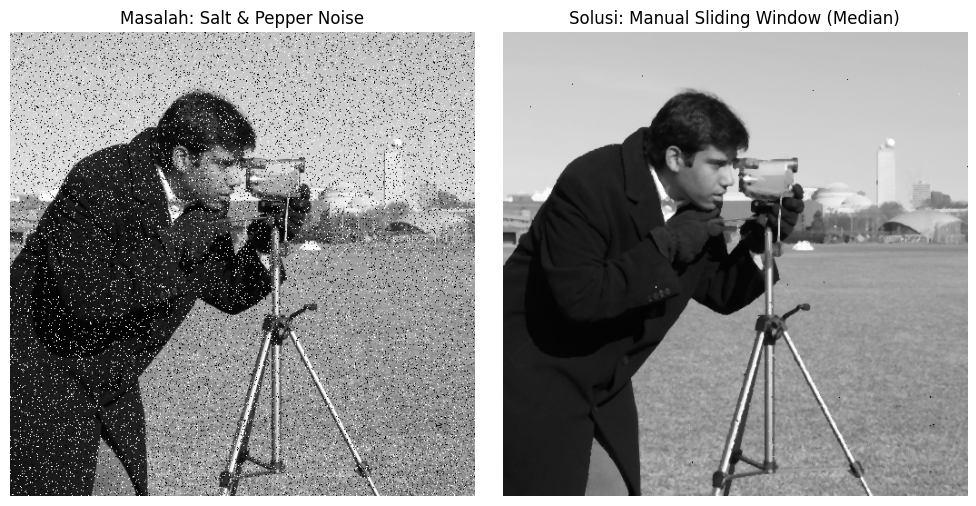

In [8]:
image_asli = data.camera()
image_noisy = np.copy(image_asli)
np.random.seed(42)

noise_salt = np.random.rand(*image_asli.shape) < 0.05
noise_pepper = np.random.rand(*image_asli.shape) < 0.05
image_noisy[noise_salt] = 255
image_noisy[noise_pepper] = 0
kernel_size = 3
pad_size = kernel_size // 2
tinggi, lebar = image_noisy.shape
image_padded = np.pad(image_noisy, pad_width=pad_size, mode='reflect')
tumpukan_tetangga = np.zeros((tinggi, lebar, kernel_size * kernel_size), dtype=np.float32)

indeks_tumpukan = 0
for i in range(kernel_size):
    for j in range(kernel_size):
        tumpukan_tetangga[:, :, indeks_tumpukan] = image_padded[i : i + tinggi, j : j + lebar]
        indeks_tumpukan += 1

image_median_filtered = np.median(tumpukan_tetangga, axis=2)
image_median_filtered = image_median_filtered.astype(np.uint8)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image_noisy, cmap='gray')
axes[0].set_title('Masalah: Salt & Pepper Noise')
axes[0].axis('off')

axes[1].imshow(image_median_filtered, cmap='gray')
axes[1].set_title('Solusi: Manual Sliding Window (Median)')
axes[1].axis('off')

plt.tight_layout()
plt.show()